In [1]:
print("all ok")

all ok


In [2]:
import sys, os

# Get project root — one level up from 'research_and_analyst'
print("Current working directory:", os.getcwd())
print("ABc",os.path.join(os.getcwd(), "../.."))
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

print("Project root added to path:", project_root)

Current working directory: /Users/madhushivagangaks/Desktop/Projects/automated-research-report-generation/research_and_analyst/notebook
ABc /Users/madhushivagangaks/Desktop/Projects/automated-research-report-generation/research_and_analyst/notebook/../..
Project root added to path: /Users/madhushivagangaks/Desktop/Projects/automated-research-report-generation


In [3]:
from research_and_analyst.utils.model_loader import ModelLoader

In [4]:
model_loader = ModelLoader()

{"timestamp": "2026-05-11T05:27:54.211897Z", "level": "info", "event": "Initializing ApiKeyManager"}
{"timestamp": "2026-05-11T05:27:54.212912Z", "level": "info", "event": "OPENAI_API_KEY loaded successfully from environment"}
{"timestamp": "2026-05-11T05:27:54.213355Z", "level": "info", "event": "GOOGLE_API_KEY loaded successfully from environment"}
{"timestamp": "2026-05-11T05:27:54.213709Z", "level": "info", "event": "GROQ_API_KEY loaded successfully from environment"}
{"path": "/Users/madhushivagangaks/Desktop/Projects/automated-research-report-generation/research_and_analyst/config/configuration.yaml", "keys": ["embedding_model", "retriever", "llm"], "timestamp": "2026-05-11T05:27:54.216778Z", "level": "info", "event": "Configuration loaded successfully"}
{"config_keys": ["embedding_model", "retriever", "llm"], "timestamp": "2026-05-11T05:27:54.217137Z", "level": "info", "event": "YAML configuration loaded successfully"}


In [5]:
llm=model_loader.load_llm()

{"provider": "groq", "model": "qwen/qwen3-32b", "timestamp": "2026-05-11T05:28:42.527196Z", "level": "info", "event": "Loading LLM"}
{"provider": "groq", "model": "qwen/qwen3-32b", "timestamp": "2026-05-11T05:28:42.600921Z", "level": "info", "event": "LLM loaded successfully"}


In [6]:
llm.invoke("Hi").content

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


'<think>\nOkay, the user said "Hi". That\'s pretty open-ended. I should respond in a friendly and welcoming way. Maybe ask how I can assist them. Keep it simple and let them know I\'m here to help with whatever they need. Don\'t want to overcomplicate the response. Just make sure it\'s polite and inviting.\n</think>\n\nHello! How can I assist you today? 😊'

In [7]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field, ConfigDict
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage,HumanMessage , SystemMessage
from langgraph.checkpoint.memory import MemorySaver

In [8]:
class Analyst(BaseModel):
    model_config = ConfigDict(extra="forbid")
    
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

In [9]:
analyst = Analyst(
    name="Madhushivaganga KS",
    role="genai eng",
    affiliation="AI Research LAB",
    description="I am genai developer as well as mentor",
    )    

In [10]:
print(analyst.persona)

Name: Madhushivaganga KS
Role: genai eng
Affiliation: AI Research LAB
Description: I am genai developer as well as mentor



In [11]:
class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [12]:
class GenerateAnalystsState(TypedDict):
    topic: str #research topic
    max_analysts: int # number of analyst
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

In [13]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [14]:
print([analyst_instructions.format(
        topic="education",
        max_analysts=4,
        human_analyst_feedback="please exaplain only on AI"
        
        )] + ["Generate the set of analysts."])

['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']


In [15]:
def create_analyst(state:GenerateAnalystsState):
    """
    it is creating my analyst
    
    """
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback","")
    
    structured_llm = llm.with_structured_output(Perspectives)
    
    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
        
        )
    analysts = structured_llm.invoke([SystemMessage(content=system_messages)]+ [HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

In [16]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Amina Zuberi', role='Public Health Policy Analyst', affiliation='World Health Organization (WHO)', description='Focuses on global health equity, vaccine distribution strategies, and pandemic preparedness. Prioritizes policy frameworks that address disparities in low-income regions.'),
  Analyst(name='Dr. Raj Patel', role='Health Technology Innovation Specialist', affiliation='Stanford University Medical Center', description='Specializes in AI-driven diagnostic tools, telemedicine accessibility, and ethical implications of health data usage. Advocates for scalable tech solutions in underserved communities.')]}

In [17]:
def human_feedback(state):
    """ No-op node that should be interrupted on """
    pass

In [18]:
def should_continue(state):
    feedback = (state.get("human_analyst_feedback") or "").strip().lower()
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END

In [19]:
from IPython.display import Image, display

## First Workflow

In [20]:
builder = StateGraph(GenerateAnalystsState)

In [21]:
builder.add_node("create_analyst",create_analyst)
builder.add_node("human_feedback", human_feedback)

In [22]:
builder.add_edge(START,"create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges("human_feedback",
                        should_continue,
                        ["create_analyst",
                        END])

In [23]:
memory = MemorySaver()

In [24]:
graph = builder.compile(interrupt_before= ["human_feedback"],checkpointer= memory)

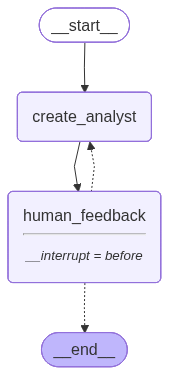

In [25]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [26]:
topic = "the benefits of adopting Langgraph as an agent framework"

In [27]:
max_analysts = 4
thread =  {"configurable":{"thread_id":1}}

In [28]:
for event in graph.stream({"topic":topic,"max_analysts":max_analysts},thread,stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Emily Carter
Affiliation: TechNova Consulting
Role: Technical Architect
Description: Focuses on Langgraph's technical scalability, performance optimization, and suitability for complex AI workflows. Concerned with system architecture trade-offs and long-term maintainability.
--------------------------------------------------
Name: Raj Patel
Affiliation: CodeCraft Innovations
Role: Lead Developer
Description: Evaluates Langgraph's developer experience, API design, and integration capabilities. Prioritizes productivity gains and ease of adoption for engineering teams.
--------------------------------------------------
Name: Sarah Lin
Affiliation: GlobalTech Financials
Role: Business Strategist
Description: Analyzes Langgraph's ROI, market differentiation potential, and alignment with enterprise AI roadmaps. Focuses on competitive advantage and business scalability.
--------------------------------------------------
Name: Michael Torres
Affiliation: EnterpriseOps Solutions
Role:

In [29]:
state = graph.get_state(thread)

In [30]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'analysts': [Analyst(name='Dr. Emily Carter', role='Technical Architect', affiliation='TechNova Consulting', description="Focuses on Langgraph's technical scalability, performance optimization, and suitability for complex AI workflows. Concerned with system architecture trade-offs and long-term maintainability."),
  Analyst(name='Raj Patel', role='Lead Developer', affiliation='CodeCraft Innovations', description="Evaluates Langgraph's developer experience, API design, and integration capabilities. Prioritizes productivity gains and ease of adoption for engineering teams."),
  Analyst(name='Sarah Lin', role='Business Strategist', affiliation='GlobalTech Financials', description="Analyzes Langgraph's ROI, market differentiation potential, and alignment with enterprise AI roadmaps. Focuses on competitive advantage and business scalability."),
  Analyst(name='Michael Torres', role='Operations Manager

In [31]:
graph.update_state(thread,{"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"},as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14cfa7-0388-670e-8002-38c1827a7af3'}}

In [32]:
for event in graph.stream({"topic":topic,"max_analysts":max_analysts},thread,stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

Name: Dr. Emily Carter
Affiliation: TechNova Consulting
Role: Technical Architect
Description: Focuses on Langgraph's technical scalability, performance optimization, and suitability for complex AI workflows. Concerned with system architecture trade-offs and long-term maintainability.
--------------------------------------------------
Name: Raj Patel
Affiliation: CodeCraft Innovations
Role: Lead Developer
Description: Evaluates Langgraph's developer experience, API design, and integration capabilities. Prioritizes productivity gains and ease of adoption for engineering teams.
--------------------------------------------------
Name: Sarah Lin
Affiliation: GlobalTech Financials
Role: Business Strategist
Description: Analyzes Langgraph's ROI, market differentiation potential, and alignment with enterprise AI roadmaps. Focuses on competitive advantage and business scalability.
--------------------------------------------------
Name: Michael Torres
Affiliation: EnterpriseOps Solutions
Role:

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Tech Startup Innovator
Affiliation: AI Startup Inc.
Role: Evaluator of agile frameworks for rapid prototyping
Description: Focuses on Langgraph's ability to enable startup teams to build and iterate autonomous agents quickly with minimal infrastructure overhead, particularly in NLP-driven applications.
--------------------------------------------------
Name: Enterprise Solutions Architect
Affiliation: Global Tech Corp
Role: Scaler of AI frameworks for large deployments
Description: Analyzes Langgraph's latest enterprise-grade features for integration with legacy systems, security compliance, and horizontal scaling in fintech and healthcare sectors.
--------------------------------------------------
Name: AI Research Framework Specialist
Affiliation: Open Source AI Lab
Role: Comparator of agent framework capabilities
Description: Examines Langgraph's modular architecture and execution engine advantages over LangChain and LlamaIndex in complex decision-tree implementations.
-------

In [33]:
state = graph.get_state(thread)

In [34]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application',
 'analysts': [Analyst(name='Tech Startup Innovator', role='Evaluator of agile frameworks for rapid prototyping', affiliation='AI Startup Inc.', description="Focuses on Langgraph's ability to enable startup teams to build and iterate autonomous agents quickly with minimal infrastructure overhead, particularly in NLP-driven applications."),
  Analyst(name='Enterprise Solutions Architect', role='Scaler of AI frameworks for large deployments', affiliation='Global Tech Corp', description="Analyzes Langgraph's latest enterprise-grade features for integration with legacy systems, security compliance, and horizontal scaling in fintech and healthcare sectors."),
  Analyst(name='AI Research Framework Specialist', role='Comparator of agent framework capabilities', affiliation='Open Source A

In [35]:
memory.storage.items()

dict_items([('1', defaultdict(<class 'dict'>, {'': {'1f14cfa6-b10a-663a-bfff-8c383d6f16a5': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-05-11T05:29:44.698414+00:00\xa2id\xd9$1f14cfa6-b10a-663a-bfff-8c383d6f16a5\xb0channel_versions\x81\xa9__start__\xd9300000000000000000000000000000001.0.5105198909994485\xadversions_seen\x81\xa9__input__\x80\xb0updated_channels\x91\xa9__start__'), ('msgpack', b'\x83\xa6source\xa5input\xa4step\xff\xa7parents\x80'), None), '1f14cfa6-b111-6b24-8000-b9d91586f0b4': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-05-11T05:29:44.701408+00:00\xa2id\xd9$1f14cfa6-b111-6b24-8000-b9d91586f0b4\xb0channel_versions\x84\xa9__start__\xd9400000000000000000000000000000002.0.04219755408853865\xa5topic\xd9400000000000000000000000000000002.0.04219755408853865\xacmax_analysts\xd9400000000000000000000000000000002.0.04219755408853865\xb8branch:to:create_analyst\xd9400000000000000000000000000000002.0.04219755408853865\xadversions_seen\x82\xa9__input__\x80\xa9__start__\x81\xa9__start_

In [36]:
state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14cfa7-31f1-67c6-8005-b3b67a7a1a6d'}}

In [37]:
graph.update_state(thread,
                   {"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"},as_node="human_feedback"
                   )

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14cfa8-2bb4-6042-8006-1826aad5324d'}}

In [38]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

Name: Tech Startup Innovator
Affiliation: AI Startup Inc.
Role: Evaluator of agile frameworks for rapid prototyping
Description: Focuses on Langgraph's ability to enable startup teams to build and iterate autonomous agents quickly with minimal infrastructure overhead, particularly in NLP-driven applications.
--------------------------------------------------
Name: Enterprise Solutions Architect
Affiliation: Global Tech Corp
Role: Scaler of AI frameworks for large deployments
Description: Analyzes Langgraph's latest enterprise-grade features for integration with legacy systems, security compliance, and horizontal scaling in fintech and healthcare sectors.
--------------------------------------------------
Name: AI Research Framework Specialist
Affiliation: Open Source AI Lab
Role: Comparator of agent framework capabilities
Description: Examines Langgraph's modular architecture and execution engine advantages over LangChain and LlamaIndex in complex decision-tree implementations.
-------

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Alex Carter
Affiliation: InnovateTech Ventures
Role: Venture Capital Analyst
Description: Focuses on startup scalability and ROI, evaluating Langgraph's potential to disrupt traditional workflow automation in emerging markets.
--------------------------------------------------
Name: Dr. Priya Rao
Affiliation: GlobalTech Solutions
Role: Enterprise AI Architect
Description: Analyzes Langgraph's integration with legacy systems and its role in enhancing real-time decision-making for large-scale operations.
--------------------------------------------------
Name: Jordan Lee
Affiliation: CodeCraft Labs
Role: Developer Advocacy Lead
Description: Highlights Langgraph's low-code capabilities and how it accelerates prototyping for agile development teams.
--------------------------------------------------
Name: Samira Khalil
Affiliation: SecureFuture Consulting
Role: Cybersecurity Strategist
Description: Examines Langgraph's security frameworks and compliance features critical for enterpri

In [39]:
state = graph.get_state(thread)

In [40]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application', 'analysts': [Analyst(name='Alex Carter', role='Venture Capital Analyst', affiliation='InnovateTech Ventures', description="Focuses on startup scalability and ROI, evaluating Langgraph's potential to disrupt traditional workflow automation in emerging markets."), Analyst(name='Dr. Priya Rao', role='Enterprise AI Architect', affiliation='GlobalTech Solutions', description="Analyzes Langgraph's integration with legacy systems and its role in enhancing real-time decision-making for large-scale operations."), Analyst(name='Jordan Lee', role='Developer Advocacy Lead', affiliation='CodeCraft Labs', description="Highlights Langgraph's low-code capabilities and how it accelerates prototyping for agile development teams."), Analyst(name='Samira Khalil', role='Cybersecuri

In [41]:
state.next

('human_feedback',)

In [42]:
# If we are satisfied, then we simply supply no feedback
further_feedack = ""

In [43]:
# 1) Get the latest state (you're paused at 'human_feedback')
state = graph.get_state(thread)

# 2) Use the exact config from that state (it already has thread_id, checkpoint_ns, checkpoint_id)
cfg = state.config

In [44]:
# 3) Update feedback at the 'human_feedback' node
#    Tip: if your TypedDict says `human_analyst_feedback: str`, prefer "" (empty string) over None
graph.update_state(cfg, {"human_analyst_feedback": ""}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14cfad-4cc6-615e-800a-d3f0c9ca0a4a'}}

In [45]:
# 4) Verify it moved to END
final_state = graph.get_state(thread)
print(final_state.next)  # should be (END,)

()


In [46]:
analysts = final_state.values.get('analysts')

In [47]:
analysts

[Analyst(name='Alex Carter', role='Venture Capital Analyst', affiliation='InnovateTech Ventures', description="Focuses on startup scalability and ROI, evaluating Langgraph's potential to disrupt traditional workflow automation in emerging markets."),
 Analyst(name='Dr. Priya Rao', role='Enterprise AI Architect', affiliation='GlobalTech Solutions', description="Analyzes Langgraph's integration with legacy systems and its role in enhancing real-time decision-making for large-scale operations."),
 Analyst(name='Jordan Lee', role='Developer Advocacy Lead', affiliation='CodeCraft Labs', description="Highlights Langgraph's low-code capabilities and how it accelerates prototyping for agile development teams."),
 Analyst(name='Samira Khalil', role='Cybersecurity Strategist', affiliation='SecureFuture Consulting', description="Examines Langgraph's security frameworks and compliance features critical for enterprise data governance.")]

In [48]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Alex Carter
Affiliation: InnovateTech Ventures
Role: Venture Capital Analyst
Description: Focuses on startup scalability and ROI, evaluating Langgraph's potential to disrupt traditional workflow automation in emerging markets.
--------------------------------------------------
Name: Dr. Priya Rao
Affiliation: GlobalTech Solutions
Role: Enterprise AI Architect
Description: Analyzes Langgraph's integration with legacy systems and its role in enhancing real-time decision-making for large-scale operations.
--------------------------------------------------
Name: Jordan Lee
Affiliation: CodeCraft Labs
Role: Developer Advocacy Lead
Description: Highlights Langgraph's low-code capabilities and how it accelerates prototyping for agile development teams.
--------------------------------------------------
Name: Samira Khalil
Affiliation: SecureFuture Consulting
Role: Cybersecurity Strategist
Description: Examines Langgraph's security frameworks and compliance features critical for enterpri

In [50]:
from langchain_community.document_loaders import WikipediaLoader

try:
	docs = WikipediaLoader(query="LangGraph").load()
	if docs:
		print(docs[0].page_content[:500])
	else:
		print("No documents found for the query.")
except Exception as e:
	print(f"An error occurred: {e}")

LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 


In [51]:
from langchain_community.document_loaders import WikipediaLoader
docs = WikipediaLoader(query="The benefits of adopting AWS Cloud").load()
print(docs[0].page_content[:500])

Cloud computing is defined by the International Organization for Standardization (ISO) as "a paradigm for enabling network access to a scalable and elastic pool of shareable physical or virtual resources with self-service provisioning and administration on demand". It is commonly referred to as "the cloud".


== Characteristics ==
In 2011, the National Institute of Standards and Technology (NIST) identified five "essential characteristics" for cloud systems. Below are the exact definitions accor


In [52]:
from langchain_community.utilities import WikipediaAPIWrapper

In [53]:
wiki = WikipediaAPIWrapper(doc_content_chars_max=4000)
docs = wiki.run("The benefits of adopting LangGraph as an agentic framework")
print(docs)

Page: Semantic Web
Summary: The Semantic Web, sometimes known as Web 3.0, is an extension of the World Wide Web through standards set by the World Wide Web Consortium (W3C). The goal of the Semantic Web is to make Internet data machine-readable.
To enable the encoding of semantics with the data, technologies such as Resource Description Framework (RDF) and Web Ontology Language (OWL) are used. These technologies are used to formally represent metadata. For example, ontology can describe concepts, relationships between entities, and categories of things. These embedded semantics offer significant advantages such as reasoning over data and operating with heterogeneous data sources.
These standards promote common data formats and exchange protocols on the Web, fundamentally the RDF. According to the W3C, "The Semantic Web provides a common framework that allows data to be shared and reused across application, enterprise, and community boundaries." The Semantic Web is therefore regarded as

## Second Workflow

In [55]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [57]:
from dotenv import load_dotenv
load_dotenv()
import os
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [58]:
tavily_api_key

'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'

In [59]:
tavily_search = TavilySearchResults(tavily_api_key=tavily_api_key)

/var/folders/fp/sr168dzs43301dnvqz4gxgqc0000gn/T/ipykernel_10877/1029971610.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(tavily_api_key=tavily_api_key)


In [60]:
tavily_search.invoke("langgraph")

[{'title': 'langgraph · PyPI',
  'url': 'https://pypi.org/project/langgraph/',
  'content': '## Core benefits\n\nLangGraph provides low-level supporting infrastructure for any long-running, stateful workflow or agent. LangGraph does not abstract prompts or architecture, and provides the following central benefits: [...] ## LangGraph’s ecosystem\n\nWhile LangGraph can be used standalone, it also integrates seamlessly with any LangChain product, giving developers a full suite of tools for building agents. To improve your LLM application development, pair LangGraph with: [...] Production-ready deployment: Deploy sophisticated agent systems confidently with scalable infrastructure designed to handle the unique challenges of stateful, long-running workflows.',
  'score': 0.99998534},
 {'title': 'LangGraph overview - Docs by LangChain',
  'url': 'https://docs.langchain.com/oss/python/langgraph/overview',
  'content': 'architectures for common LLM and tool-calling loops. LangGraph is focused 

In [61]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [62]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [63]:
question_instructions.format(goals = analyst.persona)

'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Name: Samira Khalil\nRole: Cybersecurity Strategist\nAffiliation: SecureFuture Consulting\nDescription: Examines Langgraph\'s security frameworks and compliance features critical for enterprise data governance.\n\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"\n\nRemember to stay in character throughout your response, reflecting the persona and goal

In [64]:
def generation_question(state:InterviewState):
    """Node to generate the questions"""
    
    #get state
    analyst = state["analyst"]
    messages = state["messages"]
    
    #generate the question
    system_message = question_instructions.format(goals = analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
    
    #returen the question through state
    return {"messages":[question]}

In [65]:
class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

In [66]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],"messages":[HumanMessage(content="hi do the proper search according to the experties")]}

In [67]:
result = generation_question(state)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [69]:
print(result["messages"][0].content)

<think>
Okay, I need to prepare for an interview with Samira Khalil, a Cybersecurity Strategist at SecureFuture Consulting, focusing on Langgraph's security frameworks and compliance features for enterprise data governance. Let me start by understanding who Langgraph is. From what I know, Langgraph is a company that provides tools for building and managing language models, possibly in the context of AI and machine learning. Their security frameworks would be critical for enterprises handling sensitive data.

First, I should research Langgraph's products. Maybe they have a platform that allows enterprises to deploy AI models securely. Security frameworks could include encryption, access controls, audit trails, and compliance with regulations like GDPR or HIPAA. Compliance features might involve data anonymization, secure data storage, and ensuring that AI models don't leak sensitive information.

Samira's role is to examine these aspects, so I need to ask about specific features. For ex

In [70]:
from langchain_core.messages import get_buffer_string

In [71]:
# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation. 
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query""")

In [72]:
def search_web(state:InterviewState):
    """
    Retrieve data from the web
    """
    structure_llm = llm.with_structured_output(SearchQuery)
    search_query = structure_llm.invoke([search_instructions]+state["messages"])
    
    # Search
    search_docs = tavily_search.invoke(search_query.search_query)
    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

In [73]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the strategic implications of adopting Langgraph for businesses. I'm particularly keen on how this framework can drive innovation and support digital transformation initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain what Langgraph is and why it's becoming a significant consideration for businesses looking to innovate?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [74]:
result = search_web(state)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [75]:
print(result["context"][0])

<Document href="https://www.rapidinnovation.io/post/ai-agents-in-langgraph"/>
Tailor AI solutions to meet your unique business needs.

Empowering innovation with AI-driven strategies

Leverage AI expertise to build innovative solutions

Transform your business with cutting-edge AI technologies

Craft a tailored AI roadmap for your business with our end-to-end strategy and implementation services.

Streamline repetitive tasks and optimize workflows with intelligent process automation.

Discover how AI can transform your industry. We deliver custom AI solutions.

Empowering innovation with AI-driven strategies

Leverage AI expertise to build innovative solutions

Transform your business with cutting-edge AI technologies

Anticipate trends and make proactive decisions with AI-powered predictive analytics. [...] Bridge the gap between technology and human communication with NLP solutions.

Leverage advanced computer vision technologies for image recognition, facial detection, and video ana

In [ ]:
# def search_wikipedia(state:InterviewState):
#     """
#     Retrieve data from wiki
#     """
#     # Search query
#     structured_llm = llm.with_structured_output(SearchQuery)
#     search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
#     print("*******************************")
#     print(search_query)
    
#     # Search
#     search_docs = WikipediaLoader(query=search_query.search_query).load()

#      # Format
#     formatted_search_docs = "\n\n---\n\n".join(
#         [
#             f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
#             for doc in search_docs
#         ]
#     )

#     return {"context": [formatted_search_docs]}

In [97]:
def search_wikipedia(state: InterviewState):
    # 1. Ensure the LLM actually returned something
    structured_llm = llm.with_structured_output(SearchQuery)
    try:
        search_query = structured_llm.invoke([search_instructions] + state['messages'])
    except Exception as e:
        print(f"LLM Structured Output Error: {e}")
        # Fallback logic
        return {"context": ["Error: Could not generate search query."]}

    print(f"DEBUG: Search Query is -> '{search_query.search_query}'")

    # 2. Guard against empty strings
    if not search_query.search_query.strip():
        return {"context": ["No search query generated."]}

    # 3. Search with error handling
    try:
        search_docs = WikipediaLoader(query=search_query.search_query, load_max_docs=2).load()
    except Exception as e:
        print(f"Wikipedia API Error: {e}")
        return {"context": ["Wikipedia search failed."]}

    # Formatting logic...
    formatted_search_docs = "\n\n---\n\n".join([
        f'<Document source="{doc.metadata["source"]}" />\n{doc.page_content}\n</Document>'
        for doc in search_docs
    ])

    return {"context": [formatted_search_docs]}

In [98]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the strategic implications of adopting Langgraph for businesses. I'm particularly keen on how this framework can drive innovation and support digital transformation initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain what Langgraph is and why it's becoming a significant consideration for businesses looking to innovate?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [99]:
result = search_wikipedia(state)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


DEBUG: Search Query is -> 'Langgraph strategic implications for businesses: driving innovation and digital transformation'
Wikipedia API Error: Expecting value: line 1 column 1 (char 0)


In [100]:
try:
    search_docs = WikipediaLoader(query="Langgraph framework benefits").load()
    if not search_docs:
        raise ValueError("No Wikipedia results found for 'Langgraph framework benefits'")
except Exception as e:
    print(f"WikipediaLoader failed for 'Langgraph framework benefits': {e}")
    try:
        search_docs = WikipediaLoader(query="LangGraph").load()
        if not search_docs:
            raise ValueError("No Wikipedia results found for fallback query 'LangGraph'")
    except Exception as fallback_e:
        print(f"Fallback WikipediaLoader failed: {fallback_e}")
        search_docs = []

WikipediaLoader failed for 'Langgraph framework benefits': Expecting value: line 1 column 1 (char 0)
Fallback WikipediaLoader failed: Expecting value: line 1 column 1 (char 0)


In [101]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [102]:
def generate_answer(state:InterviewState):
    """ Node to answer a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    # Append it to state
    return {"messages": [answer]}

In [103]:
def route_messages(state: InterviewState, name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    
    return "ask_question"

In [104]:
def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}

In [105]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [106]:
def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}

In [107]:
interview_builder = StateGraph(InterviewState)

In [108]:
interview_builder.add_node("ask_question",generation_question)
interview_builder.add_node("search_web",search_web)
interview_builder.add_node("search_wikipedia",search_wikipedia)
interview_builder.add_node("generate_answer",generate_answer)
interview_builder.add_node("save_interview",save_interview)
interview_builder.add_node("write_section",write_section)

In [109]:
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question","search_web")
interview_builder.add_edge("ask_question","search_wikipedia")
interview_builder.add_edge("search_web","generate_answer")
interview_builder.add_edge("search_wikipedia","generate_answer")
interview_builder.add_conditional_edges("generate_answer",route_messages,["ask_question","save_interview"])
interview_builder.add_edge("save_interview","write_section")
interview_builder.add_edge("write_section",END)

In [110]:
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name = "Conduct Interview")

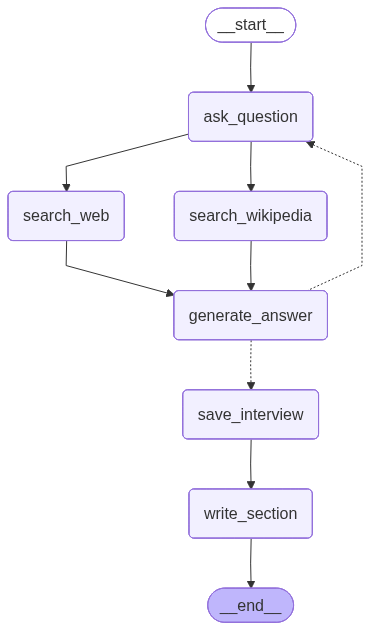

In [111]:
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [112]:
from IPython.display import Markdown

In [113]:
messages = [HumanMessage("So you said you were writing an article on Langchain?")]

In [114]:
interview = interview_graph.invoke({"analyst": analyst, "messages": messages, "max_num_turns": 2}, thread)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


DEBUG: Search Query is -> 'Langchain security framework compared to Langgraph: stateful execution, compliance-as-code, dependency security, real-world use cases in finance/healthcare'


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 33.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 7.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 23.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [115]:
Markdown(interview['sections'][0])

<think>
Okay, let's start by understanding the user's query. They want me to create a report section based on the provided source documents, focusing on LangGraph's security frameworks and compliance features for enterprise data governance. 

First, I need to analyze the documents. The first document is a GitHub repository listing various tools related to software supply chain security, including AI BOM generators like Trusera/ai-bom which scans LangGraph workflows. The second document from OpenCVE.io details specific vulnerabilities in LangGraph, such as a Remote Code Execution vulnerability in the caching layer and a query injection in Redis checkpoint. The third document from GitLab discusses dependency scanning using SBOMs, which is relevant for compliance. The fourth article from InnovationND highlights critical vulnerabilities in LangChain and LangGraph, emphasizing the need for audits and security measures. The last document from ENISA talks about SBOMs for supplier security evaluation and compliance.

The user wants the report to be engaging, so the title should reflect the critical security aspects of LangGraph. The summary needs to provide context on enterprise data governance, mention the vulnerabilities found, and highlight the tools and frameworks that address these issues. I need to reference the sources in order, ensuring no duplicates. 

I should start by outlining the title, then the summary with background, key points from the sources, and a numbered list of sources. The sources section must list all the documents used with their links. I need to make sure the summary is concise, around 400 words, and uses the sources correctly. Also, check for any redundant links and combine them as instructed. Finally, review the structure to ensure it follows the markdown format with the correct headers and formatting.
</think>

## LangGraph Security Frameworks and Compliance: Enterprise Risks and Mitigation Strategies  

### Summary  
LangGraph, a key component in AI/LLM workflows, faces critical security and compliance challenges highlighted by recent vulnerabilities and enterprise governance demands. A Remote Code Execution (RCE) flaw in LangGraph’s caching layer (CVE-2026-27022) allows attackers to exploit deserialization vulnerabilities when using unsecured cache backends like Redis or SQLite [2]. Similarly, query injection risks in Redis checkpoint implementations (CVE-2026-27794) enable bypassing access controls through unescaped user input [2]. These flaws underscore the need for runtime protections, such as KTH-LangSec/nodeshield, which enforces SBOM/CBOM policies to prevent supply chain attacks [1].  

For compliance, tools like Trusera/ai-bom generate AI Bills of Materials (AI BOMs) for LangGraph workflows, producing CycloneDX/SPDX formats to document dependencies and provenance [1]. GitLab’s dependency scanning using SBOMs offers a model for enterprises, automating vulnerability detection in transitive dependencies and aligning with industry standards [3]. ENISA emphasizes SBOMs as critical for evaluating supplier security practices and license compliance, directly addressing risks like those in LangGraph’s ecosystem [4].  

Notably, the InnovationND article warns enterprises to audit AI frameworks like LangGraph, treating them with the same rigor as production databases due to their access to sensitive data and API keys [4]. The disclosed vulnerabilities—enabling file theft, API key exfiltration, and conversation history pilfering—highlight the urgency of patching and adopting least-privilege configurations [4].  

### Sources  
[1] https://github.com/bureado/awesome-software-supply-chain-security  
[2] https://app.opencve.io/cve/?vendor=langchain-ai&product=langgraph  
[3] https://docs.gitlab.com/user/application_security/dependency_scanning/dependency_scanning_sbom/  
[4] https://www.innovationnd.com/articles/intel/langchain-langgraph-ai-stack-liability-march-2026  
[5] https://www.enisa.europa.eu/sites/default/files/2025-12/SBOM%20Analysis%20-%20Towards%20an%20Implementation%20Guide_v1.20-Published.pdf

## Third Workflow

In [117]:
from typing_extensions import TypedDict
from typing import List, Annotated
import operator
class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report
    
# class InterviewState(MessagesState):
#     max_num_turns: int # Number turns of conversation
#     context: Annotated[list, operator.add] # Source docs
#     analyst: Analyst # Analyst asking questions
#     interview: str # Interview transcript
#     sections: list # Final key we duplicate in outer state for Send() API

In [118]:
from langgraph.types import Send

In [119]:
def initiate_all_interviews(state:ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """ 
    
    #check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"
    
    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                        "messages": [HumanMessage(
                                            content=f"So you said you were writing an article on {topic}?"
                                        )
                                                ]}) for analyst in state["analysts"]]

In [120]:
report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

In [121]:
def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

In [122]:
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

In [123]:
def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

In [124]:
def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

In [125]:
def finalize_report(state: ResearchGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

In [126]:
# Add nodes and edges 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analyst)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)

In [127]:
memory = MemorySaver()

In [128]:
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

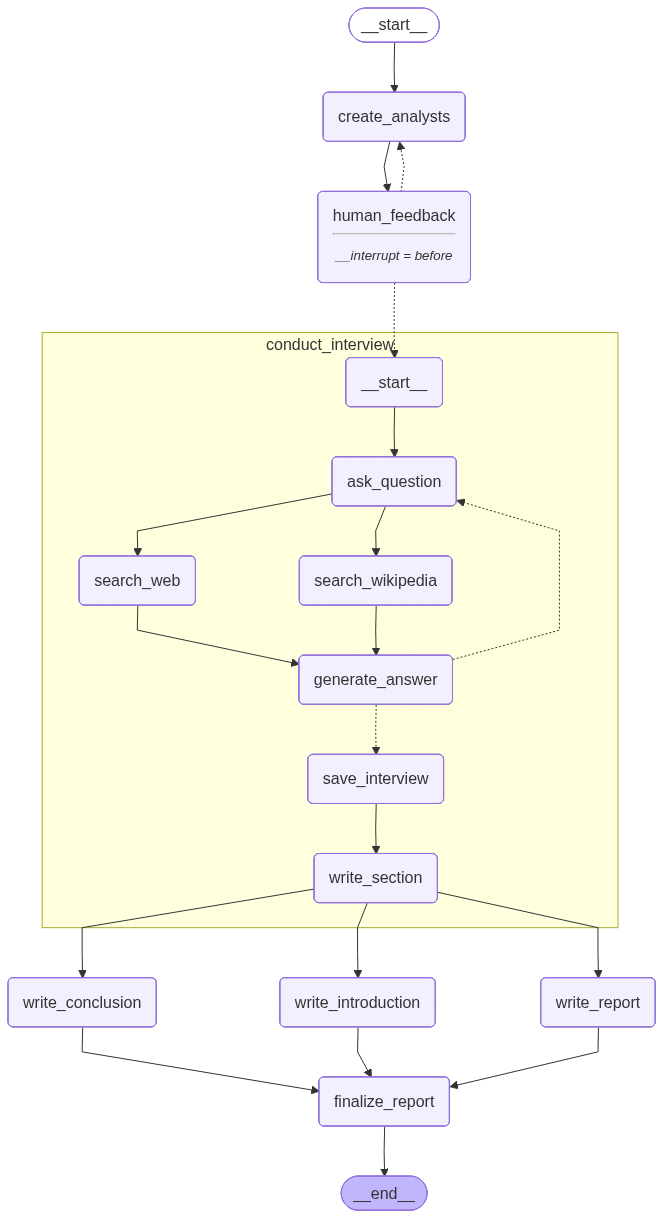

In [129]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [130]:
max_analysts = 3

In [131]:
topic = "How can generative AI be used in shaping new technologies?"

In [132]:
thread = {"configurable": {"thread_id": "1"}}

In [133]:
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Elena Martinez
Affiliation: Global AI Ethics Institute
Role: AI Ethics Researcher
Description: Focuses on ethical implications of generative AI in technology development, advocating for responsible innovation and policy frameworks to mitigate bias and societal risks.
--------------------------------------------------
Name: Dr. Raj Patel
Affiliation: Tech Innovations Lab
Role: Generative AI Lead Researcher
Description: Explores cutting-edge applications of generative AI in engineering and scientific discovery, emphasizing technical advancements and novel use cases.
--------------------------------------------------
Name: Sarah Kim
Affiliation: FutureTech Consulting Group
Role: Technology Market Strategist
Description: Analyzes economic and industrial transformations driven by generative AI, focusing on market disruption, business model evolution, and competitive dynamics.
--------------------------------------------------


In [134]:
graph.update_state(thread, {"human_analyst_feedback":"along with the how it will impact the changing world"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14d356-aba2-6b30-8002-5161f48e8c11'}}

In [135]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Elena Martinez
Affiliation: Global AI Ethics Institute
Role: AI Ethics Researcher
Description: Focuses on ethical implications of generative AI in technology development, advocating for responsible innovation and policy frameworks to mitigate bias and societal risks.
--------------------------------------------------
Name: Dr. Raj Patel
Affiliation: Tech Innovations Lab
Role: Generative AI Lead Researcher
Description: Explores cutting-edge applications of generative AI in engineering and scientific discovery, emphasizing technical advancements and novel use cases.
--------------------------------------------------
Name: Sarah Kim
Affiliation: FutureTech Consulting Group
Role: Technology Market Strategist
Description: Analyzes economic and industrial transformations driven by generative AI, focusing on market disruption, business model evolution, and competitive dynamics.
--------------------------------------------------


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Elena Martinez
Affiliation: Global AI Ethics Institute
Role: Ethical AI Researcher
Description: Focuses on the ethical implications of generative AI in technology development, advocating for frameworks that ensure fairness, transparency, and societal benefit while mitigating risks like bias and job displacement.
--------------------------------------------------
Name: Raj Patel
Affiliation: FutureTech Labs
Role: Tech Innovation Strategist
Description: Explores how generative AI accelerates breakthroughs in fields like biotechnology, quantum computing, and sustainable energy, emphasizing collaboration between AI systems and human creativity to solve global challenges.
--------------------------------------------------
Name: Sophia Kim
Affiliation: Global Economic Policy Council
Role: Economic Impact Analyst
Description: Analyzes the economic transformation driven by generative AI, including the rise of AI-generated industries, shifts in labor markets, and the creation of new f

In [136]:
graph.update_state(thread, {"human_analyst_feedback":""}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14d357-b246-6314-8006-e62c176a1886'}}

In [137]:
graph.get_state(thread).next

('conduct_interview', 'conduct_interview', 'conduct_interview')

In [138]:
# Continue
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


DEBUG: Search Query is -> 'Challenges and solutions in integrating generative AI into biotechnology and quantum computing, focusing on interpretability and explainable AI frameworks'


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 7.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 11.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 11.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 46.

LLM Structured Output Error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `qwen/qwen3-32b` in organization `org_01kd33xzhqf2m8627r5dcgc6sw` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 4535, Requested 1880. Please try again in 4.15s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


DEBUG: Search Query is -> 'ethical risks generative AI collaborative innovation black box problem accountability explainability AI decision-making'


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 14.000000 seconds


Wikipedia API Error: Expecting value: line 1 column 1 (char 0)


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 10.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 16.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 20.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 413 Payload Too Large"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 10.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `qwen/qwen3-32b` in organization `org_01kd33xzhqf2m8627r5dcgc6sw` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 4069, Requested 2380. Please try again in 4.49s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [139]:
from IPython.display import Markdown

In [140]:
final_state = graph.get_state(thread)

In [141]:
report = final_state.values.get('final_report')

In [ ]:
Markdown(report)

<IPython.core.display.Markdown object>
